In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#provided MHW value for your site in [m NAVD88]
MHW_ELEVATION_NAVD88 = 0.26 
#load the water level csv file for year 2024 [m NAVD88]
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/Daily_WL_NAVD.csv'

#load water level
water_NAVD_df = pd.read_csv(water_level_NAVD) # (m NAVD88)
daily_tidal_levels_NAVD= water_NAVD_df['v'].values # (m NAVD88)
#converting daily water level (m NAVD88) to (m MHW)
daily_tidal_MHW = daily_tidal_levels_NAVD - MHW_ELEVATION_NAVD88 # (m MHW)

#loading CASCADE simulations
data = np.load (
    '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Nourishment_S0_Accretional_Sink.npz', allow_pickle=True)
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Nourishment_S0_Accretional_Sink.npz' with keys: cascade

In [144]:
cascade_object = data['cascade'][0]


In [145]:
#exporting road elevations (m MHW) for each domain categorized by the years
results_list = []
target_years = [25, 26, 27, 28, 29,
                         30, 31, 32, 33, 34,
                         35, 36, 37, 38, 39,
                         40, 41, 42, 43, 44,
                         45, 46, 47, 48, 49, 50]
 
if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            
            #  DOMAINS 14 to 54
            if 14 <= i <= 54:
            
                elevation_time_series = road_segment._road_ele_TS
                elevation = elevation_time_series[year]
                elev_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation (m MHW)': elevation
                }
                results_list.append(elev_row)

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    road_df = pd.DataFrame(results_list)
    output_filename = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink_RoadElevation25to50.csv'

    road_df.to_csv(output_filename, index=False)
    print("Data for domains 14-54 successfully exported. First 5 rows:")
    print(road_df.head())

Data for domains 14-54 successfully exported. First 5 rows:
   Year  Domain  Road_Elevation (m MHW)
0    25      14                0.000000
1    25      15                1.232148
2    25      16                1.232148
3    25      17                1.232148
4    25      18                1.232148


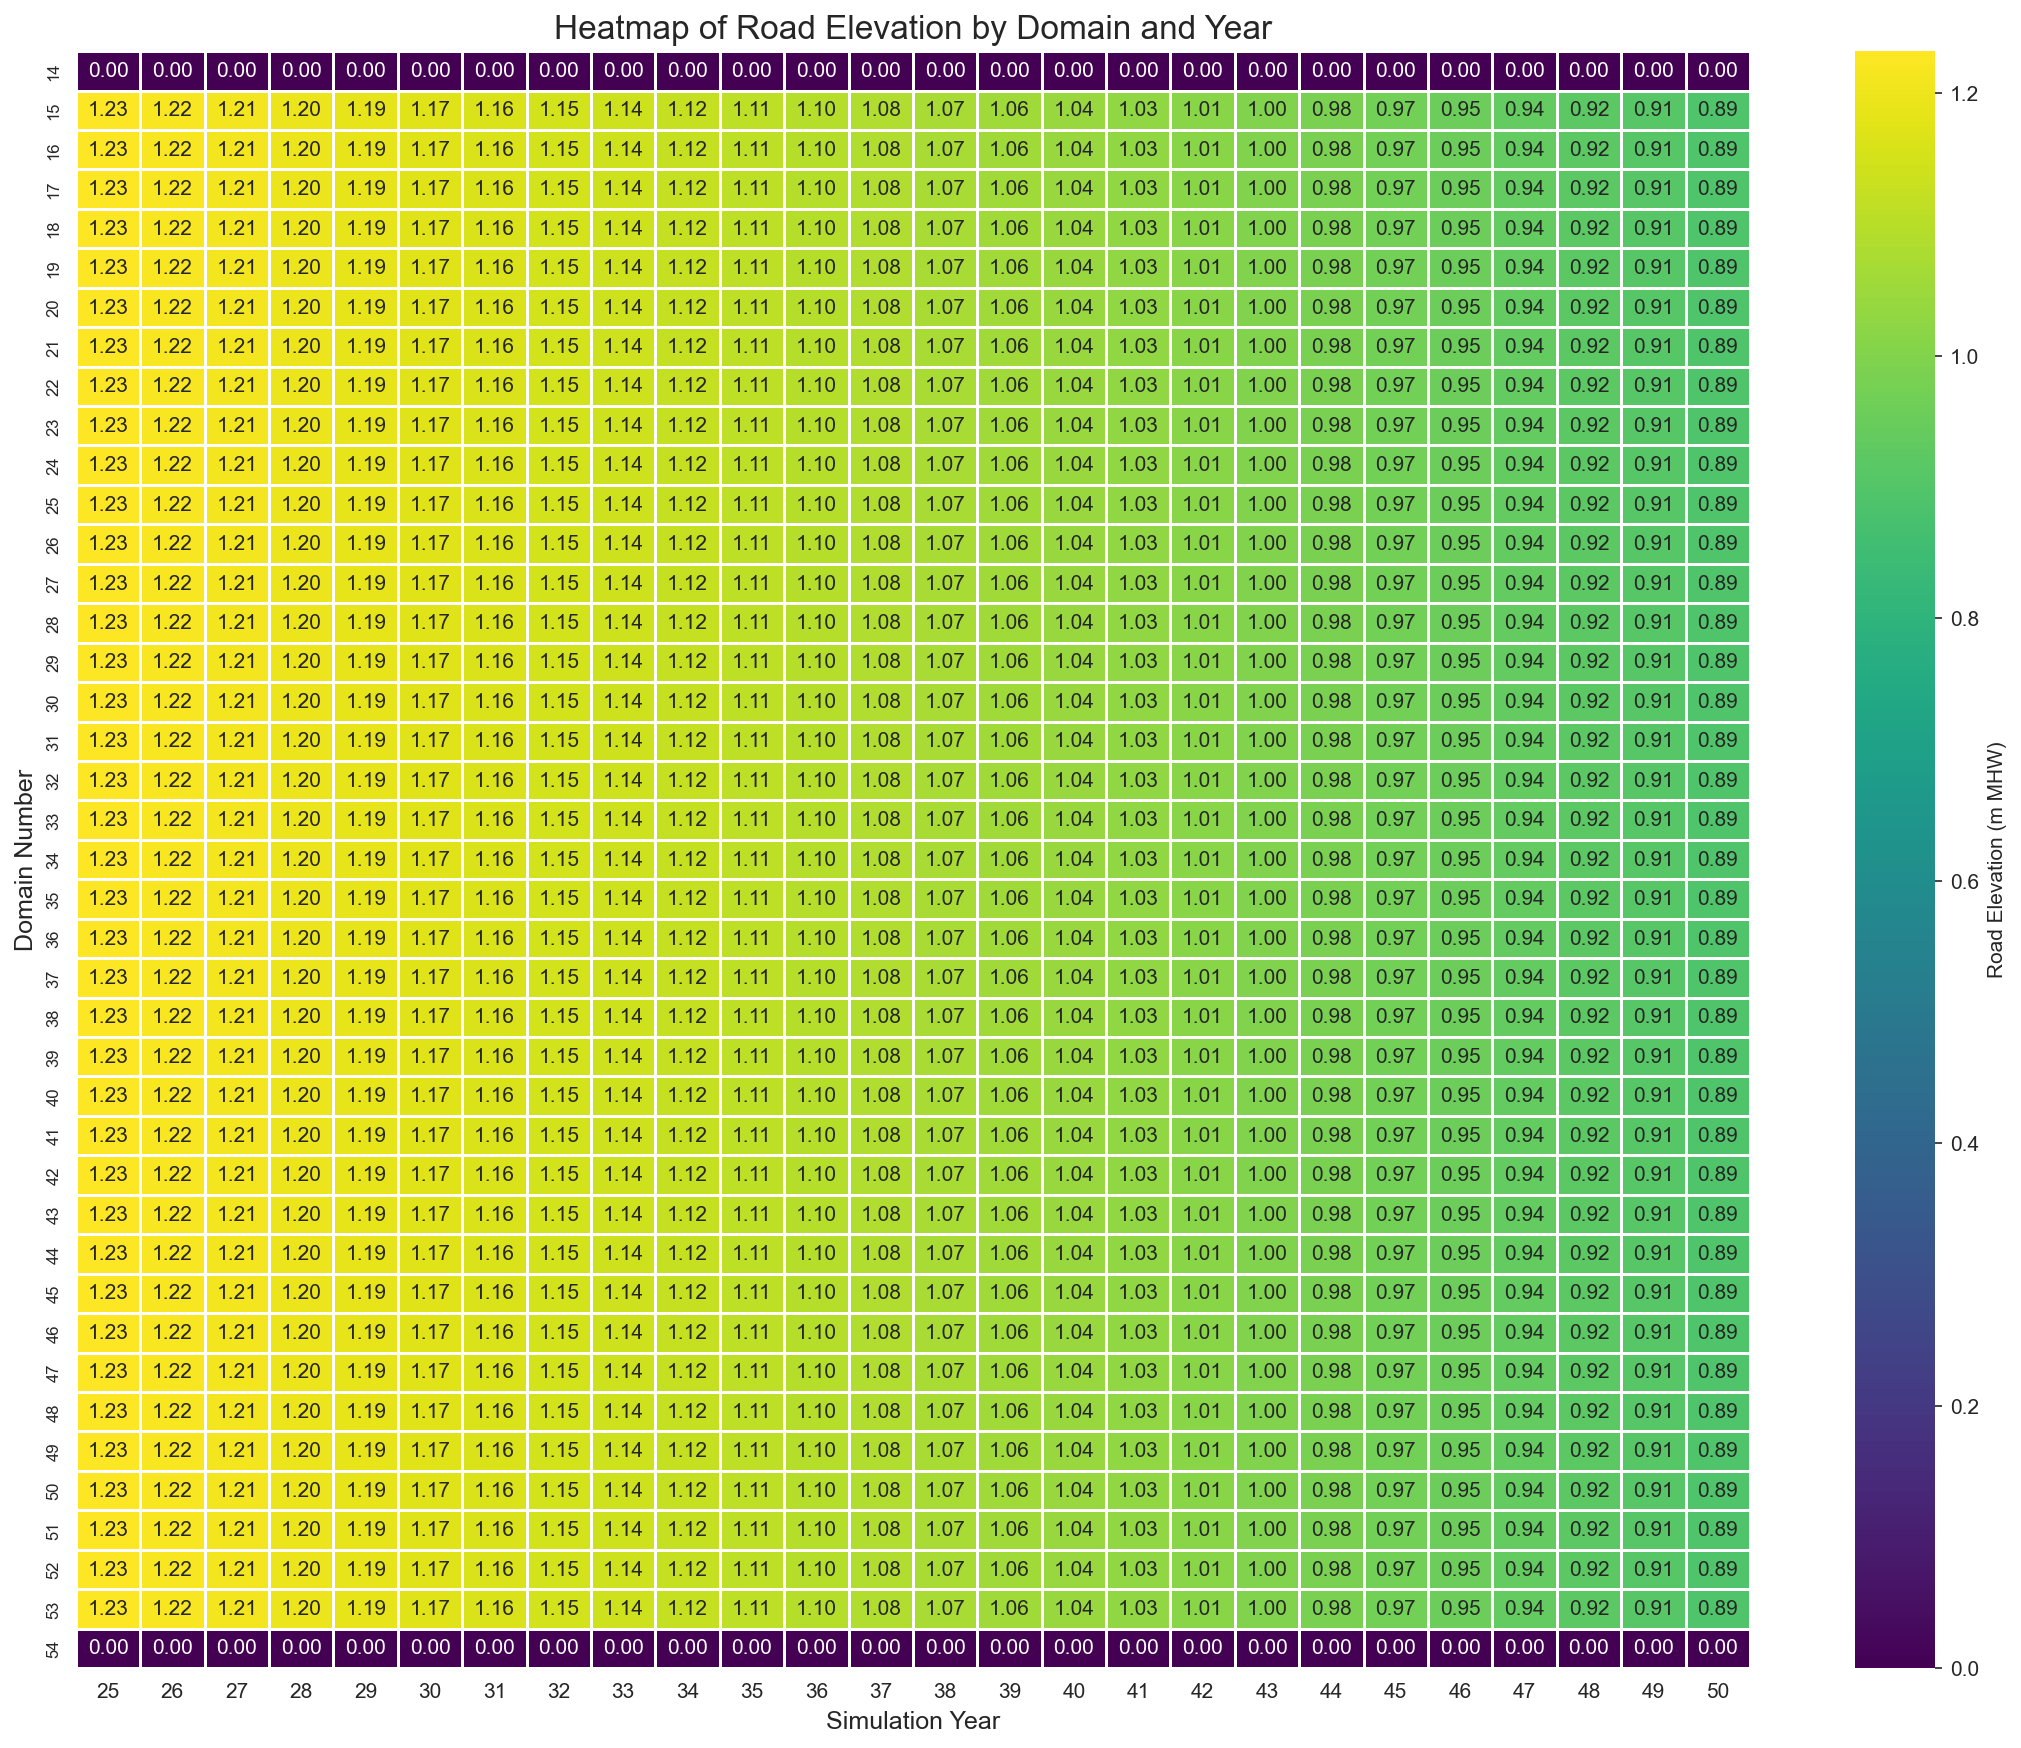

In [146]:
#plotting road elevation
# Load the CSV file into a DataFrame
file_path = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink_RoadElevation25to50.csv'
df = pd.read_csv(file_path)

# Reshape the data using a pivot_table for the heatmap
heatmap_data = df.pivot_table(index='Domain', columns='Year', values='Road_Elevation (m MHW)')

# Create the heatmap plot
plt.figure(figsize=(18, 14), dpi=150)
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".2f", 
                 cmap='viridis', 
                 linewidths=.5,
                 cbar_kws={'label': 'Road Elevation (m MHW)'})


ax.tick_params(axis='y', labelsize=8)

plt.title('Heatmap of Road Elevation by Domain and Year', fontsize=16)
plt.ylabel('Domain Number', fontsize=12)
plt.xlabel('Simulation Year', fontsize=12)

# Show the plot
plt.show()

In [140]:
#export flood days to csv
analysis_output_filepath = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink_flood_days25to50.csv'
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation (m MHW)']
    flooded_days = np.sum(road_elevation < daily_tidal_MHW)
    
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation': road_elevation,
        'Flooded_Days': flooded_days,
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file
results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink_flood_days25to50.csv'


In [147]:
#export flood depth to csv
analysis_output_filepath = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink_flood_depth25to50.csv'
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation (m MHW)']
    
    # flood days and depth analysis
    # Identify which days are flooded
    is_flooded = road_elevation < daily_tidal_MHW
    flooded_days = np.sum(is_flooded)
    
    # Calculate flood depth only on the days it flooded
    max_flood_depth = 0
    avg_flood_depth = 0
    
    if flooded_days > 0:
        # Calculate the depth for all flooded days
        flood_depths = daily_tidal_MHW[is_flooded] - road_elevation # (m MHW)
        
        # Find the maximum and average flood depth for the year
        max_flood_depth = np.max(flood_depths)
        avg_flood_depth = np.mean(flood_depths)

    # export the results
        
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation': road_elevation, # (m MHW)
        'Flooded_Days': flooded_days,
        'Max_Flood_Depth_m_MHW': max_flood_depth,   # (m MHW)
        'Avg_Flood_Depth_m_MHW': avg_flood_depth,   # (m MHW)
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file
results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink_flood_depth25to50.csv'


  > Plot saved as '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink25to50.png'


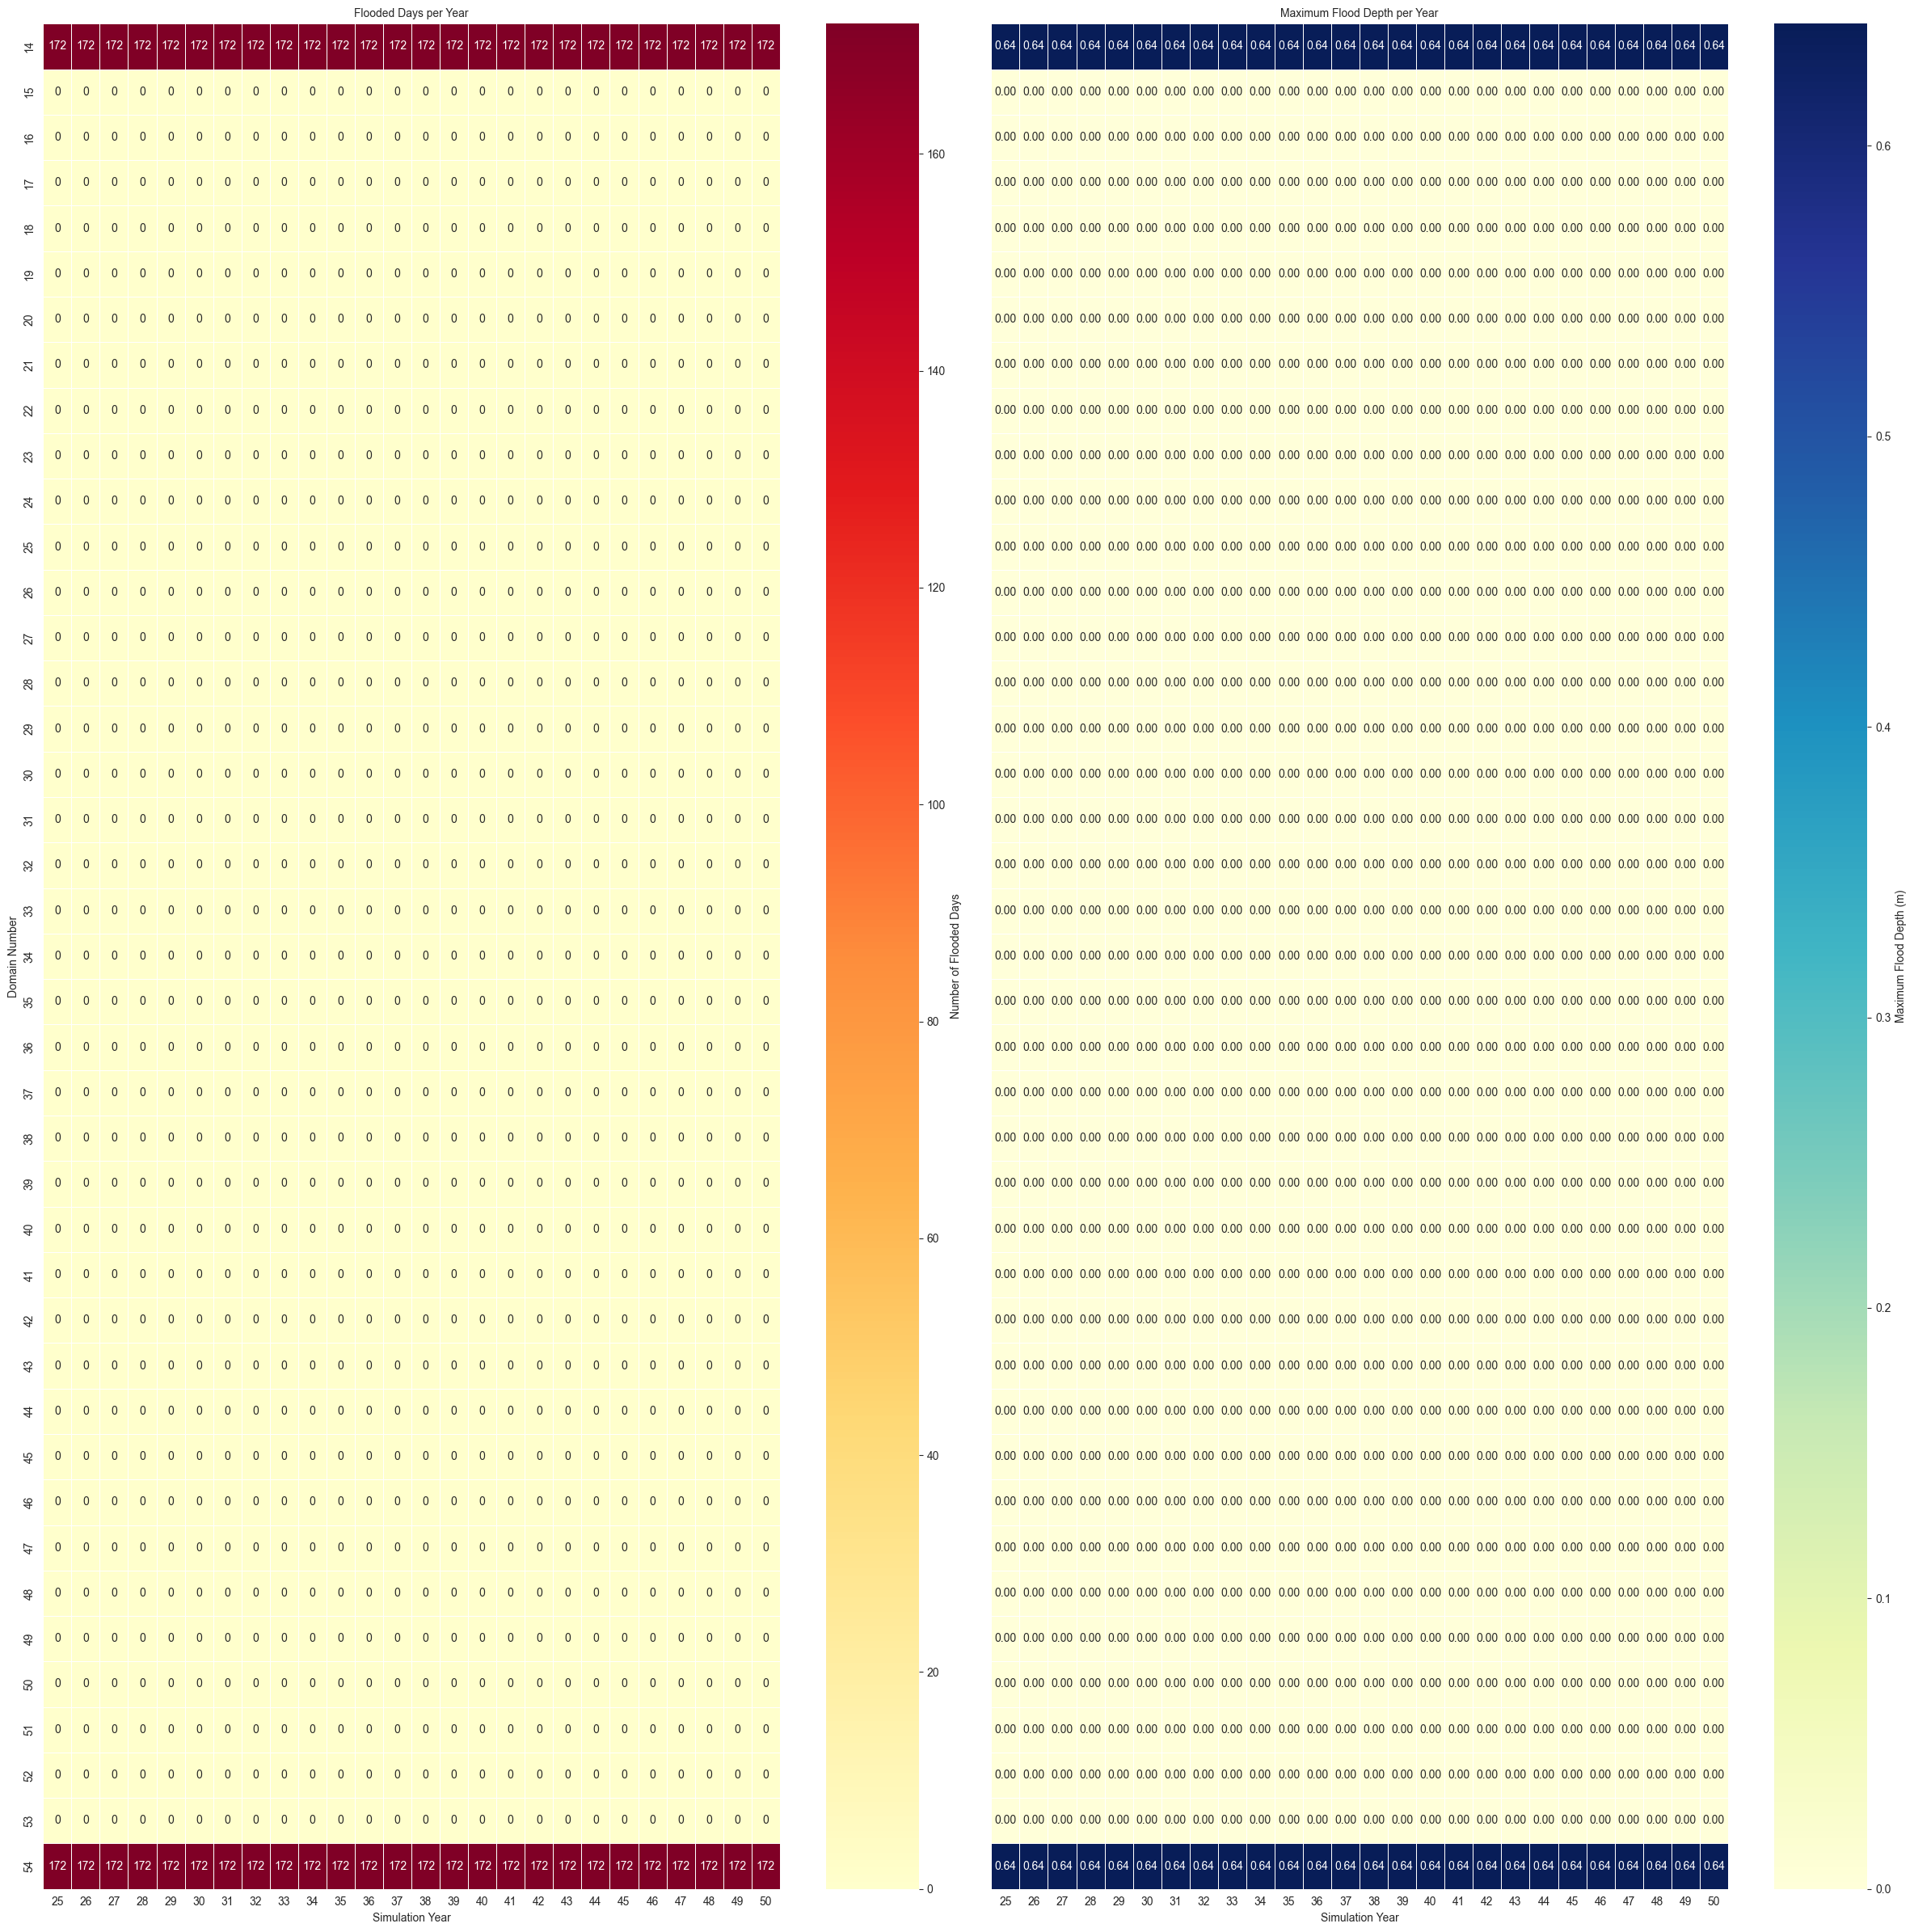

In [148]:
plt.rcParams.update({'font.size': 10})
# Create two pivot tables, one for each variable
heatmap_days = results_df.pivot_table(index='Domain', columns='Year', values='Flooded_Days')
heatmap_depth = results_df.pivot_table(index='Domain', columns='Year', values='Max_Flood_Depth_m_MHW')

# Create a figure with two subplots 
fig, axes = plt.subplots(1, 2, figsize=(24, 24), sharey=True) # sharey=True aligns the domain rows
sns.set_style("whitegrid")

text_props = dict(ha='center', va='center', fontsize=10, color='black', weight='bold')
bbox_props = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1, alpha=0.8)

# Plot 1: Flooded Days 
sns.heatmap(heatmap_days, ax=axes[0], annot=True, fmt=".0f", cmap='YlOrRd', 
            linewidths=.5, cbar_kws={'label': 'Number of Flooded Days'})
axes[0].set_title('Flooded Days per Year', fontsize=10)
axes[0].set_ylabel('Domain Number', fontsize=10)
axes[0].set_xlabel('Simulation Year', fontsize=10)

# Plot 2: Maximum Flood Depth 
sns.heatmap(heatmap_depth, ax=axes[1], annot=True, fmt=".2f", cmap='YlGnBu', 
            linewidths=.5, cbar_kws={'label': 'Maximum Flood Depth (m)'})
axes[1].set_title('Maximum Flood Depth per Year', fontsize=10)
axes[1].set_ylabel('') # Hide the y-label to avoid repetition
axes[1].set_xlabel('Simulation Year', fontsize=10)
# plt.text(1.75, 7.5, 'Buffer Zone', **text_props, bbox=bbox_props)
# plt.text(1.75, 34.5, 'Ocracoke Island', **text_props, bbox=bbox_props)
# plt.text(1.75, 61.5, 'Buffer Zone', **text_props, bbox=bbox_props)

# Add horizontal lines to both plots
for ax in axes:
    # ax.axhline(y=15, color='black', linestyle='--', linewidth=3)
    # ax.axhline(y=54, color='black', linestyle='--', linewidth=3)
    ax.set_xticklabels(['25', '26', '27', '28', '29',
                         '30', '31', '32', '33', '34',
                         '35', '36', '37', '38', '39',
                         '40', '41', '42', '43', '44',
                         '45', '46', '47', '48', '49', '50']) 

plt.tight_layout() # Adjusts plots to prevent them from overlapping


plot_output_filename = f'/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/OCR_I_Nourishment_S0_Accretional_Sink25to50.png'
plt.savefig(plot_output_filename, bbox_inches='tight')
print(f"  > Plot saved as '{plot_output_filename}'")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Let's assume 'cascade_object' is your loaded object from the .npz file

# A list to store the data from each row
results_list = []

# Determine the number of years from the simulation output
# and create a list of all years to process.
if cascade_object.roadways:
    target_years = [25, 26, 27, 28, 29,
                         30, 31, 32, 33, 34,
                         35, 36, 37, 38, 39,
                         40, 41, 42, 43, 44,
                         45, 46, 47, 48, 49, 50]

    # Use nested loops to iterate through each year and each domain
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways[14:55], start=14):
            # Get the corresponding barrier3d segment for the same domain
            barrier3d_segment = cascade_object.barrier3d[i]
            
            # Extract each variable for the current year and domain
            # We use a try-except block to handle potential missing data gracefully
            try:
                elevation = road_segment._road_ele_TS[year]
                width = barrier3d_segment.InteriorWidth_AvgTS[year]
                setback = road_segment._road_setback_TS[year]
                qow = barrier3d_segment.QowTS[year]
                shoreline_change = barrier3d_segment.ShorelineChangeTS[year]
                dune_height = barrier3d_segment.Hd_AverageTS[year]
                overwash_vol = road_segment._road_overwash_volume[year]
                
                # Create a dictionary for the current row
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Elevation': elevation,
                    'InteriorWidth_Avg': width,
                    'RoadSetback': setback,
                    'Qow': qow,
                    'ShorelineChange': shoreline_change,
                    'AvgDuneHeight': dune_height,
                    'RoadOverwashVolume_m3': overwash_vol
                }
                results_list.append(result_row)
            
            except IndexError:
                print(f"Data for Year {year}, Domain {i} is not available. Skipping.")

    # Convert the list of dictionaries into a pandas DataFrame
    if results_list:
        results_df = pd.DataFrame(results_list)
        
        # Define a new output filename
        output_filename = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/25to50/combined_cascade_variables.csv'
        
        # Save the DataFrame to the new CSV file
        results_df.to_csv(output_filename, index=False)
        
        print(f"All specified variables successfully exported to '{output_filename}'")
        print("First 5 rows of the new file:")
        print(results_df.head())
else:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")